# Detección de contornos

En este cuaderno vas a estudiar cómo una región binaria se convierte en un borde que OpenCV puede recorrer y dibujar. Primero vamos a usar formas simples y después vamos a transferir la idea a una imagen real.


## Objetivo

Entender el pasaje máscara -> contorno y reconocer por qué la calidad de la máscara condiciona completamente el resultado final.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- construir una máscara binaria controlada;
- usar `cv2.findContours()` para recuperar bordes;
- filtrar contornos por área;
- transferir el procedimiento a una imagen real segmentada por color.

## Relación con la secuencia

Este cuaderno prepara el terreno para medir propiedades geométricas. Antes de hablar de área, perímetro o centroides, conviene entender de dónde sale exactamente el contorno.


## Módulos que vamos a usar

- `cv2`: para construir máscaras, encontrar contornos y dibujarlos.
- `numpy`: para crear imágenes binarias simples.
- `matplotlib.pyplot`: para visualizar cada etapa.
- `pathlib.Path`: para abrir la imagen real de transferencia.


In [1]:
from pathlib import Path # para cargar imágenes

import cv2 # procesamiento de imágenes
import numpy as np #para crear imágenes artificiales
import matplotlib.pyplot as plt #mostrar resultados


## 1. Empezar con una máscara simple

Cuando el objetivo es entender cómo funciona `findContours`, conviene empezar con una imagen binaria controlada. Así el foco queda en el mecanismo y no en errores previos de segmentación.


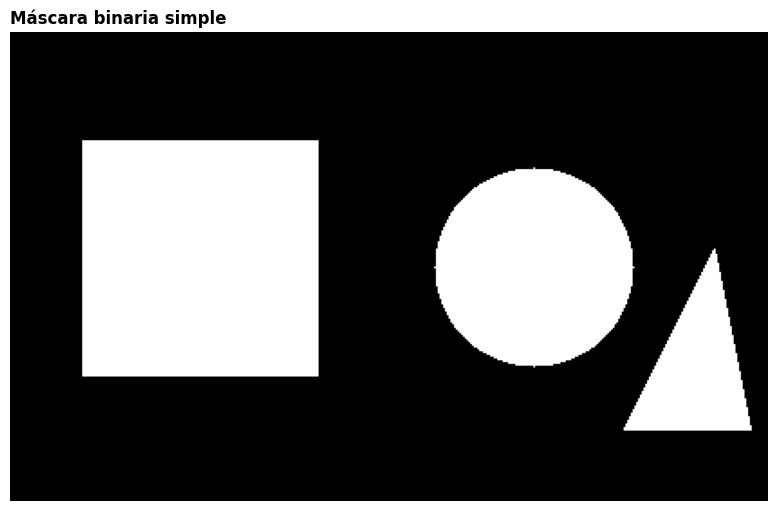

In [2]:
mascara_simple = np.zeros((260, 420), dtype=np.uint8) #Crea una imagen de 260 filas x 420 columnas, arrancando en negro toda la imagen
cv2.rectangle(mascara_simple, (40, 60), (170, 190), 255, -1) #se dibuja un rectangulo dentro de la mascara, se definen las esquinas sup izq e inf der, color blanco y relleno completo
cv2.circle(mascara_simple, (290, 130), 55, 255, -1) #se dibuja un circulo, con coordenadas de centro, radio, color y relleno
puntos_triangulo = np.array([[340, 220], [390, 120], [410, 220]], dtype=np.int32) #se define un triangulo con los puntos de vertice
cv2.fillPoly(mascara_simple, [puntos_triangulo], 255) #se dibuja el triangulo uniendo los puntos y se rellena de blanco

#Gráfico

plt.figure(figsize=(8, 5), constrained_layout=True)
plt.imshow(mascara_simple, cmap="gray")
plt.title("Máscara binaria simple", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Encontrar y dibujar contornos

`cv2.findContours()` no devuelve una imagen lista. Devuelve una lista de curvas. Después nosotros decidimos cómo mostrarlas.


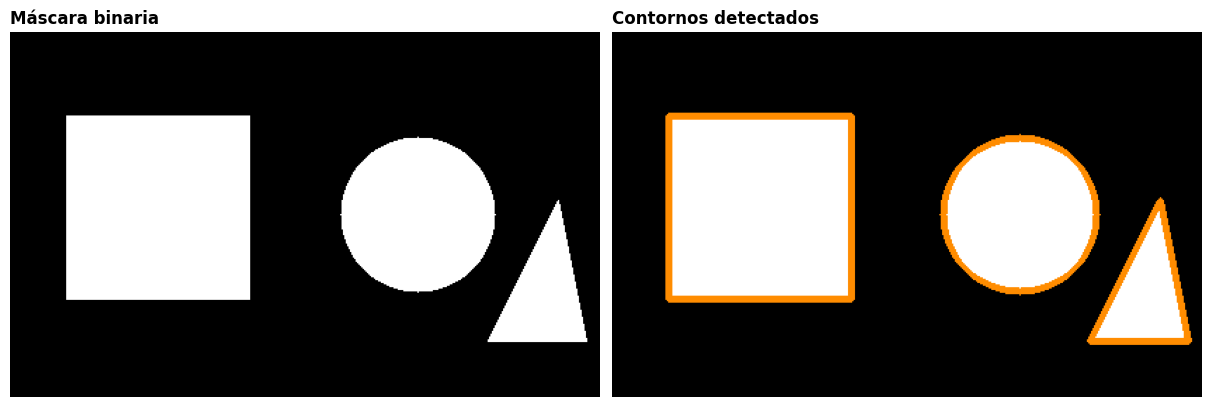

Cantidad de contornos detectados: 3


In [3]:
contornos_simples, _ = cv2.findContours(mascara_simple.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) #busca los bordes de las zonas blancas usando una copia de la imagen para no alterar la original
#detecta solo los contornos externos para detectar las figuras
#simplifica los puntos de contorno guardando las esquinas que lo determinan

imagen_contornos_simple = cv2.cvtColor(mascara_simple, cv2.COLOR_GRAY2RGB) #convierte la imagen de escala de grises a RGB para que el color del borde se distinga
cv2.drawContours(imagen_contornos_simple, contornos_simples, -1, (255, 140, 0), 3) # se define donde, qué dibujar, los contornos, el color y grosor de la línea.

fig, ejes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True) #imprime los graficos juntos (mascara-contornos)
ejes[0].imshow(mascara_simple, cmap="gray")  #muestra la imagen original en blanco y negro
ejes[0].set_title("Máscara binaria", fontweight="bold", loc="left") #muestra la imagen original en blanco y negro
ejes[0].axis("off") #muestra la imagen original en blanco y negro
ejes[1].imshow(imagen_contornos_simple) #muestra la copia con los bordes dibujados
ejes[1].set_title("Contornos detectados", fontweight="bold", loc="left") #muestra la copia con los bordes dibujados
ejes[1].axis("off") #muestra la copia con los bordes dibujados
plt.show()

print(f"Cantidad de contornos detectados: {len(contornos_simples)}") #cuenta cuántos objetos encontró


En este ejemplo la relación entre máscara y contorno es directa. Eso ayuda a entender que el contorno no “descubre” el objeto por sí solo: sigue el borde de lo que la máscara ya definió como región blanca.


## 3. Transferir la idea a una imagen real

Ahora vamos a pasar a una imagen de globos. En este caso, primero necesitamos construir una máscara de color y después recién buscar los contornos.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
ruta_globos = Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/005/004 - computer_vision_parte_1/Imagenes/globos.jpg")
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)
#cargamos la imagen, convertimos la ruta en string para que la detecte cv2.imread, le indicamos a opencv que lea la imagen en color y la guardamos en formato RGB en el orden que lee opencv
if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}") #manejo de errores al cargar la imagen

imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB) #cv2.cvtcolor convierte la imagen de un espacio de color a otro, pasando de BGR a RGB
#cambiamos el espacio porque matplotlib espera RGB
imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV) #aca convertimos la imagen de BGR a HSV, para facilitar el aislamiento de un color en específico
#definir el limite inferior del color naranja
rango_naranja_bajo = np.array([8, 80, 80], dtype=np.uint8) #define el rango minimo aceptado paea que el pixel sea de color naranja , indicando tono (hue), saturación (Saturation) y brillo (Value)
# de este modo sólo se consideran los pixels con un tono cercano al naranja, con suficiente saturación y brillo.
#definir el limite superior del color naranja
rango_naranja_alto = np.array([22, 255, 255], dtype=np.uint8) #se indica el valor maximo aceptado para el pixel naranja indicando tono (hue), saturación (Saturation) y brillo (Value)
#asi queda definido el rango de color completo que quiero detectar

#Máscaras

mascara_naranja = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo, rango_naranja_alto) #revisa cada pixel de la imagen si esta dentro del rango lo pone en color blanco, sino en negro
#resultando una imagen binaria donde el blanco son las zonas naranja detectadas y el negro es el resto de la imagen

#limpiar ruidos
#elimina pequeños puntos blancos que no pertenecen al objeto
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1) #kernel o ventana de 5x5, con 1 iteracion
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_CLOSE, np.ones((5, 5), dtype=np.uint8), iterations=2)#kernel o ventana de 5x5, con 2 iteraciones para reforzar el efecto

#En resumen, en esta celda se carga una imagen, se convierte de RGB-BGR-HSV, busca los pixeles naranjas, genera una máscara binaria y luego la limpia para detectar los contornos.


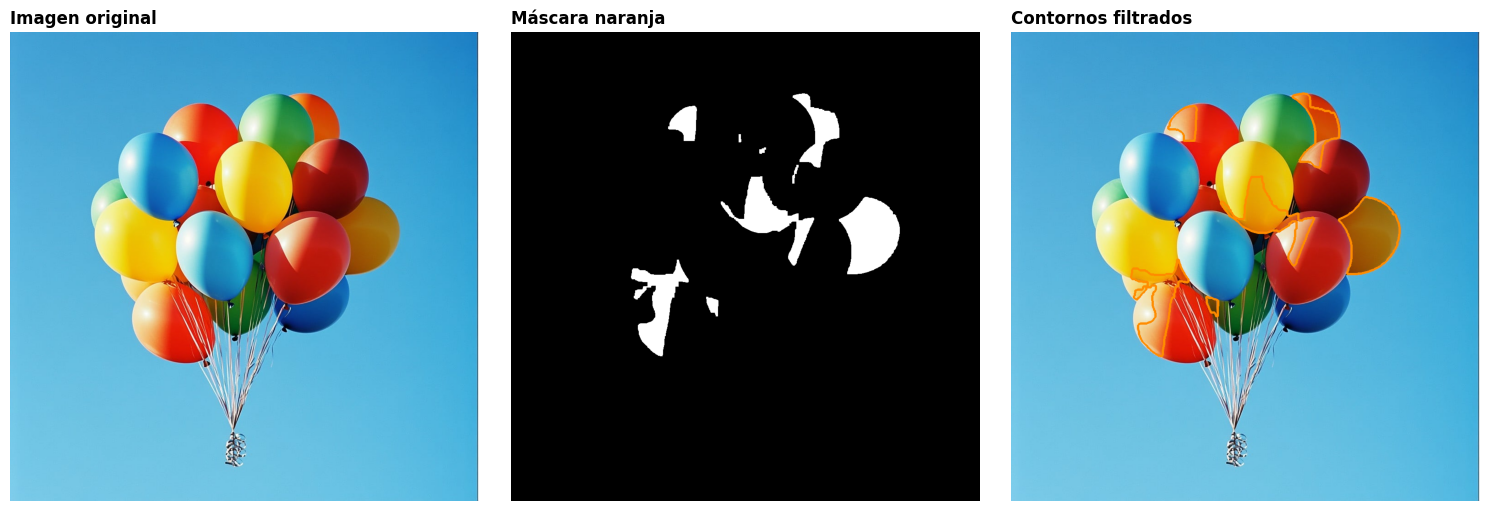

Contornos antes del filtrado: 9
Contornos conservados: 6


In [8]:
contornos_reales, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) #ahora con una imagen real busca zonas blancas en la mascara, para cada zona blanca determina un contorno, identifica ruidos

contornos_filtrados = [] #en esta lista se guardan los contornos que quisieramos filtrar
for contorno in contornos_reales: #iteramos en cada uno, calcula el tamaño y solo deja pasar los > al umbral de 500 para eliminar ruido
    if cv2.contourArea(contorno) > 500:
        contornos_filtrados.append(contorno) #si pasan el filtro, los agrega a la lista

imagen_con_contornos = imagen_globos_rgb.copy() #copia la imagen original para dibujar sobre la misma los contornos
cv2.drawContours(imagen_con_contornos, contornos_filtrados, -1, (255, 140, 0), 3) # dibuja todos los contornos en color naranja y grosor 3 para detectar los globos con el borde

#Se crean las imagenes comparativas imagen original-máscara-resultado final
fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_globos_rgb) #ver el contexto real
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_naranja, cmap="gray") #ver que detectó como naranja
ejes[1].set_title("Máscara naranja", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_contornos) #solo globos detectados, sin ruido
ejes[2].set_title("Contornos filtrados", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

#muestra cuántos contornos detecta inicialmente y cuntos quedan luego de eliminar el ruido
print(f"Contornos antes del filtrado: {len(contornos_reales)}")
print(f"Contornos conservados: {len(contornos_filtrados)}")


Fijate que la calidad del contorno depende totalmente de la máscara. Si la segmentación deja ruido o se come partes del objeto, el contorno también queda mal. Por eso conviene pensar estas etapas como una cadena y no como funciones aisladas.


## Actividad breve

Modificá el rango de color o el criterio de área mínima y volvé a ejecutar el proceso. Después explicá:

1. qué cambió en la máscara;
2. qué cambió en los contornos detectados;
3. cuál sería un criterio razonable para decidir si un contorno vale la pena conservar.


##Cambios en el rango de color

Ampliamos el rango y conservamos el umbral

In [9]:
ruta_globos = Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/005/004 - computer_vision_parte_1/Imagenes/globos.jpg")
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)

if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}")

imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)

imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV)


#cambiamos el rango del limite inferior [8,80,80] por uno más amplio
rango_naranja_bajo = np.array([5, 60, 60], dtype=np.uint8) #define el rango minimo aceptado paea que el pixel sea de color naranja , indicando tono (hue), saturación (Saturation) y brillo (Value)

#cambiamos el rango del limite superior [22,255,255] por uno más amplio
rango_naranja_alto = np.array([25, 255, 255], dtype=np.uint8)


mascara_naranja = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo, rango_naranja_alto)



mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_CLOSE, np.ones((5, 5), dtype=np.uint8), iterations=2)


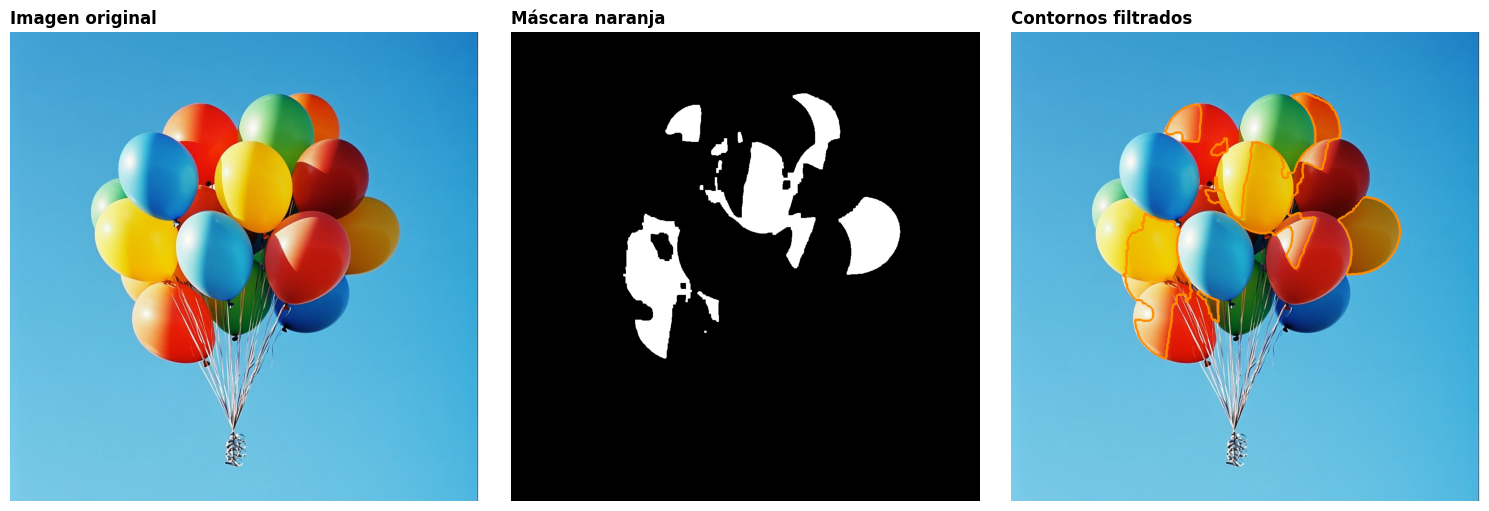

Contornos antes del filtrado: 10
Contornos conservados: 6


In [10]:
contornos_reales, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contornos_filtrados = []
for contorno in contornos_reales: #iteramos en cada uno, calcula el tamaño y solo deja pasar los > al umbral de 500 para eliminar ruido
    if cv2.contourArea(contorno) > 500: #NO MODIFICAMOS EL UMBRAL
        contornos_filtrados.append(contorno) #si pasan el filtro, los agrega a la lista

imagen_con_contornos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos, contornos_filtrados, -1, (255, 140, 0), 3)


fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_globos_rgb) #ver el contexto real
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_naranja, cmap="gray") #ver que detectó como naranja
ejes[1].set_title("Máscara naranja", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_contornos) #solo globos detectados, sin ruido
ejes[2].set_title("Contornos filtrados", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

#muestra cuántos contornos detecta inicialmente y cuántos quedan luego de eliminar el ruido
print(f"Contornos antes del filtrado: {len(contornos_reales)}")
print(f"Contornos conservados: {len(contornos_filtrados)}")

¿Qué cambió en los contornos detectados?
Los contornos ahora son más completos y abarcan mayor superficie
Algunos contornos que antes podían estar fragmentados ahora aparecen más unidos
También pueden aparecer contornos adicionales o menos precisos, ya que el rango más amplio incluye más colores

Es decir, los contornos rodean mejor a los globos pero tambien se vuelve más impreciso en algunas zonas.

¿Cuál sería un criterio razonable para conservar contornos?
Un criterio adecuado sería utilizar el área del contorno como filtro:
Conservar contornos con un área suficientemente grande, que representen objetos reales (globos)
Descartar contornos pequeños, ya que suelen corresponder a ruido o detecciones irrelevantes

En otras palabras los objetos reales ocupan mucho espacio en la imagen y el ruido ocupa muy poco espacio, lo cual me garantiza que si tomo un entorno grande es mas probable que capte los globos y no el ruido

En este caso un umbral >500 permite eliminar ruido sin perder los objetos principales

##Conservamos los rangos y ampliamos el umbral

In [11]:
ruta_globos = Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/005/004 - computer_vision_parte_1/Imagenes/globos.jpg")
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)

if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}")

imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)

imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV)


#cambiamos el rango del limite inferior [8,80,80] por uno más amplio
rango_naranja_bajo = np.array([5, 60, 60], dtype=np.uint8) #define el rango minimo aceptado paea que el pixel sea de color naranja , indicando tono (hue), saturación (Saturation) y brillo (Value)

#cambiamos el rango del limite superior [22,255,255] por uno más amplio
rango_naranja_alto = np.array([25, 255, 255], dtype=np.uint8)


mascara_naranja = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo, rango_naranja_alto)



mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_CLOSE, np.ones((5, 5), dtype=np.uint8), iterations=2)

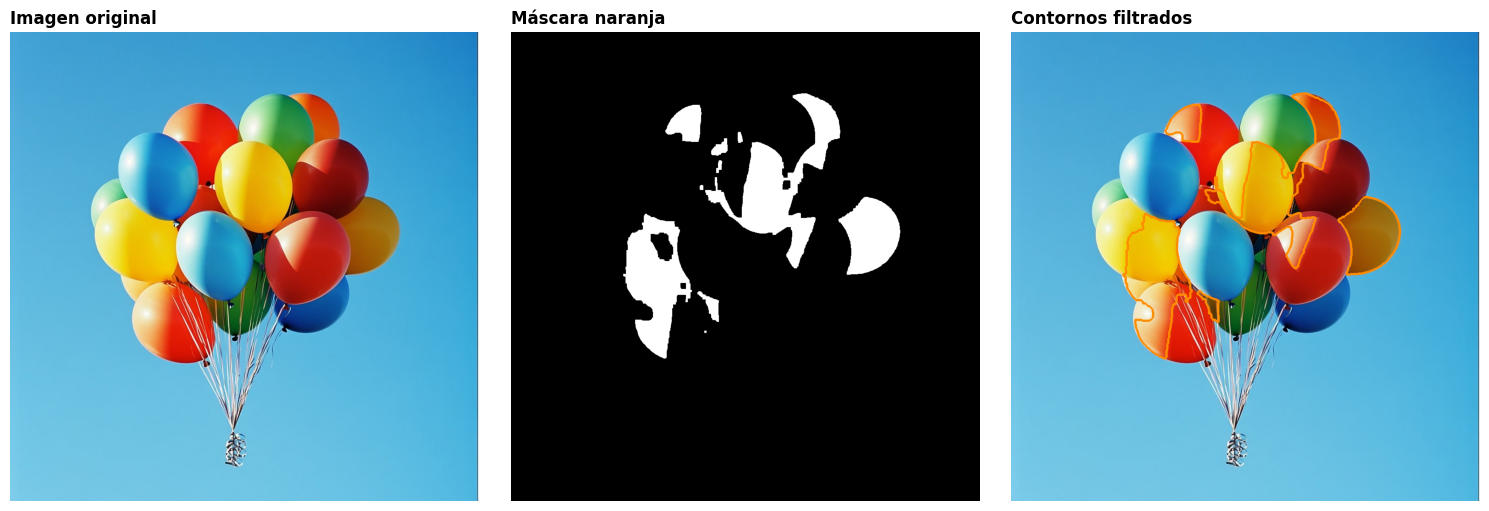

Contornos antes del filtrado: 10
Contornos conservados: 5


In [12]:
contornos_reales, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contornos_filtrados = []
for contorno in contornos_reales: #iteramos en cada uno, calcula el tamaño y solo deja pasar los > al umbral de 500 para eliminar ruido
    if cv2.contourArea(contorno) > 1000: #AMPLIAMOS EL UMBRAL
        contornos_filtrados.append(contorno) #si pasan el filtro, los agrega a la lista

imagen_con_contornos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos, contornos_filtrados, -1, (255, 140, 0), 3)


fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_globos_rgb) #ver el contexto real
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_naranja, cmap="gray") #ver que detectó como naranja
ejes[1].set_title("Máscara naranja", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_contornos) #solo globos detectados, sin ruido
ejes[2].set_title("Contornos filtrados", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

#muestra cuántos contornos detecta inicialmente y cuántos quedan luego de eliminar el ruido
print(f"Contornos antes del filtrado: {len(contornos_reales)}")
print(f"Contornos conservados: {len(contornos_filtrados)}")

¿Qué cambió en la máscara?

La máscara no presentó cambios, ya que el rango de color utilizado para detectar el naranja se mantuvo igual.

¿Qué cambió en los contornos detectados?
Al aumentar el umbral de área mínima, se redujo la cantidad de contornos conservados. Los contornos más pequeños desaparecieron, ya que fueron considerados ruido o detecciones poco relevantes. Como resultado, los contornos restantes corresponden principalmente a las partes más grandes de los globos, logrando una detección más limpia pero menos detallada.

¿Cuál sería un criterio razonable para conservar contornos?
Un criterio razonable es conservar aquellos contornos cuya área sea suficientemente grande como para representar un objeto real de interés, como los globos, y descartar los contornos pequeños que suelen corresponder a ruido o errores de segmentación.


#TRADEOFF

Se observa un trade-off entre el rango de color y el umbral de área. Un rango de color más amplio permite detectar más regiones del objeto de interés, pero puede incorporar ruido. Por otro lado, un umbral de área más alto reduce el ruido, aunque puede eliminar partes relevantes de los objetos. Por lo tanto, es necesario encontrar un equilibrio entre ambos parámetros para lograr una detección precisa sin perder información importante.

## Cierre

Detectar contornos no es solo llamar a `findContours()`. Antes hace falta una máscara que represente bien el objeto de interés. Cuando esa etapa previa está bien resuelta, el contorno se vuelve una herramienta muy útil para medir, comparar y describir formas.
